<a href="https://colab.research.google.com/github/ngocbichnguyen/wqu_projects/blob/main/MScFE_660_Risk_Management_GW1_16529_Codework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MScFE 660 Risk Management — Group Work Project 1
## Executable Google Colab Notebook
### Problem Formulation and Data Collection for Crude Oil Price Forecasting Using Probabilistic Graphical Models


**Notebook purpose.** This notebook supports the GWP1 report template by producing: data acquisition, data dictionary, data cleaning, distributional plots, time-series plots, multivariate plots, stylized-facts diagnostics, a preliminary probabilistic-graphical-model structure, Markov-blanket analysis, and pseudocode for inferred causality.

**Execution design.** In Google Colab, the notebook first tries to download live public data from FRED and Yahoo Finance. If internet access or a package is unavailable, the notebook automatically creates a reproducible demonstration dataset so that every cell remains executable and all outputs/figures are generated.

In [48]:
# ============================================================
# 0. Environment setup
# ============================================================
import sys, subprocess, importlib, warnings, math, os
warnings.filterwarnings("ignore")

# In Google Colab, optional packages can be installed automatically.
# In restricted/offline environments, this is skipped so the notebook remains executable.
IN_COLAB = "google.colab" in sys.modules
RUN_OPTIONAL_INSTALLS = IN_COLAB  # Set to True manually in Colab if a package is missing.

optional_packages = {
    "yfinance": "yfinance",
    "pandas_datareader": "pandas_datareader",
}
for pip_name, import_name in optional_packages.items():
    try:
        importlib.import_module(import_name)
    except Exception:
        if RUN_OPTIONAL_INSTALLS:
            try:
                subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
            except Exception as e:
                print(f"Optional package not installed: {pip_name}. Live data may be skipped. Reason: {e}")
        else:
            print(f"Optional package unavailable in this environment: {pip_name}. Live data may be skipped.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
import networkx as nx

try:
    from statsmodels.tsa.stattools import acf
    from statsmodels.stats.diagnostic import acorr_ljungbox
    STATSMODELS_AVAILABLE = True
except Exception:
    STATSMODELS_AVAILABLE = False
    print("statsmodels unavailable. Some autocorrelation diagnostics will be skipped.")

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except Exception:
    YFINANCE_AVAILABLE = False

try:
    from pandas_datareader import data as pdr
    FRED_AVAILABLE = True
except Exception:
    FRED_AVAILABLE = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True

print("Environment ready.")
print("Running in Google Colab:", IN_COLAB)
print("YFinance available:", YFINANCE_AVAILABLE)
print("FRED reader available:", FRED_AVAILABLE)
print("Statsmodels available:", STATSMODELS_AVAILABLE)

Environment ready.
Running in Google Colab: True
YFinance available: True
FRED reader available: True
Statsmodels available: True


## 1. Research design and variable map

The target variable is the crude oil price or its log return. The modelling logic follows the report template: crude oil prices are treated as the outcome of macroeconomic/geopolitical conditions, microeconomic oil-market fundamentals, and financial-market expectations. The final Bayesian-network stage uses discretized states because many introductory Bayesian-network algorithms are most stable when variables are categorical.

In [49]:
# ============================================================
# 1. Project configuration
# ============================================================
CONFIG = {
    "start_date": "2004-01-01",
    "end_date": pd.Timestamp.today().strftime("%Y-%m-%d"),
    "monthly_frequency": "M",
    "target_price": "Brent_Spot",
    "target_return": "Brent_Return",
    "use_live_data": IN_COLAB,  # In Colab: live public data; offline build: reproducible fallback
    "allow_synthetic_fallback": True,
    "random_seed": 660
}

# FRED series: if a series is unavailable, the code skips it and continues.
fred_series = {
    # Target and financial-market variables
    "Brent_Spot": "DCOILBRENTEU",       # Europe Brent Spot Price FOB, USD/bbl
    "WTI_Spot": "DCOILWTICO",           # WTI Spot Price, USD/bbl
    "VIX": "VIXCLS",                    # CBOE Volatility Index
    "OVX": "OVXCLS",                    # CBOE Crude Oil ETF Volatility Index (if available)
    "US_10Y_Yield": "DGS10",            # 10-Year Treasury Constant Maturity Rate
    "USD_Broad_Index": "DTWEXBGS",      # Trade Weighted U.S. Dollar Index, Broad

    # Macroeconomic variables
    "US_Industrial_Production": "INDPRO",
    "US_CPI": "CPIAUCSL",
    "US_Fed_Funds": "FEDFUNDS"
}

# EIA API: Microeconomic/oil-market variables.
eia_api = {
    "US_Crude_Stocks": "WCESTUS1",
    "US_Crude_Production": "WCRFPUS2",
    "US_Refinery_Inputs": "WCRRIUS2"
}

yahoo_tickers = {
    "Brent_Futures": "BZ=F",
    "WTI_Futures": "CL=F",
    "SP500": "^GSPC",
    "Dollar_Index": "DX-Y.NYB"
}

data_dictionary_template = pd.DataFrame([
    ["Brent_Spot", "Target / Financial", "Europe Brent crude spot price", "Daily", "FRED / EIA", "Log return", "Primary oil price target", "Student C"],
    ["WTI_Spot", "Financial", "West Texas Intermediate spot price", "Daily", "FRED / EIA", "Log return", "Comparable crude oil benchmark", "Student C"],
    ["VIX", "Financial", "Equity-market implied volatility", "Daily", "FRED / CBOE", "Level / change", "Risk appetite proxy", "Student C"],
    ["OVX", "Financial", "Crude-oil implied volatility", "Daily", "FRED / CBOE", "Level / change", "Oil volatility proxy", "Student C"],
    ["US_10Y_Yield", "Macro/Financial", "U.S. 10-year Treasury yield", "Daily", "FRED", "First difference", "Discount-rate and macro proxy", "Student A"],
    ["USD_Broad_Index", "Macro/Financial", "Broad U.S. dollar index", "Daily", "FRED", "Log return", "Dollar-denominated oil-price channel", "Student A"],
    ["US_Industrial_Production", "Macroeconomic", "U.S. industrial production index", "Monthly", "FRED", "Log difference", "Real-activity proxy", "Student A"],
    ["US_CPI", "Macroeconomic", "U.S. consumer price index", "Monthly", "FRED", "Log difference", "Inflation proxy", "Student A"],
    ["US_Fed_Funds", "Macroeconomic", "Effective federal funds rate", "Monthly", "FRED", "First difference", "Monetary-policy proxy", "Student A"],
    ["US_Crude_Stocks", "Microeconomic", "U.S. crude oil stocks", "Weekly", "EIA API", "Change", "Inventory/supply-demand balance", "Student B"],
    ["US_Crude_Production", "Microeconomic", "U.S. crude oil field production", "Weekly", "EIA API", "Log difference", "Supply proxy", "Student B"],
    ["US_Refinery_Inputs", "Microeconomic", "U.S. refinery crude inputs", "Weekly", "EIA API", "Log difference", "Refinery demand proxy", "Student B"],
    ["SP500", "Financial", "S&P 500 index", "Daily", "Yahoo Finance", "Log return", "Risk-on market proxy", "Student B"],
    ["Dollar_Index", "Financial", "U.S. dollar index", "Daily", "Yahoo Finance", "Log return", "FX proxy", "Student B"],
], columns=["Variable", "Category", "Definition", "Frequency", "Source", "Transformation", "Use", "Responsible"])

data_dictionary_template

,Variable,Category,Definition,Frequency,Source,Transformation,Use,Responsible
0,Brent_Spot,Target / Financial,Europe Brent crude spot price,Daily,FRED / EIA,Log return,Primary oil price target,Student C
1,WTI_Spot,Financial,West Texas Intermediate spot price,Daily,FRED / EIA,Log return,Comparable crude oil benchmark,Student C
2,VIX,Financial,Equity-market implied volatility,Daily,FRED / CBOE,Level / change,Risk appetite proxy,Student C
3,OVX,Financial,Crude-oil implied volatility,Daily,FRED / CBOE,Level / change,Oil volatility proxy,Student C
4,US_10Y_Yield,Macro/Financial,U.S. 10-year Treasury yield,Daily,FRED,First difference,Discount-rate and macro proxy,Student A
5,USD_Broad_Index,Macro/Financial,Broad U.S. dollar index,Daily,FRED,Log return,Dollar-denominated oil-price channel,Student A
6,US_Industrial_Production,Macroeconomic,U.S. industrial production index,Monthly,FRED,Log difference,Real-activity proxy,Student A
7,US_CPI,Macroeconomic,U.S. consumer price index,Monthly,FRED,Log difference,Inflation proxy,Student A
8,US_Fed_Funds,Macroeconomic,Effective federal funds rate,Monthly,FRED,First difference,Monetary-policy proxy,Student A
9,US_Crude_Stocks,Microeconomic,U.S. crude oil stocks,Weekly,EIA API,Change,Inventory/supply-demand balance,Student B


## 2. Data acquisition

The next cell attempts to download live public data. If the live retrieval fails, a demonstration dataset is generated with economically plausible dynamics: supply shocks, volatility clustering, correlated macro variables, inventory movements and financial risk proxies.

In [50]:
import sys, subprocess, importlib, warnings, math, os
warnings.filterwarnings("ignore")

# In Google Colab, optional packages can be installed automatically.
# In restricted/offline environments, this is skipped so the notebook remains executable.
IN_COLAB = "google.colab" in sys.modules
RUN_OPTIONAL_INSTALLS = IN_COLAB  # Set to True manually in Colab if a package is missing.

optional_packages = {
    "yfinance": "yfinance",
    "pandas_datareader": "pandas_datareader",
}
for pip_name, import_name in optional_packages.items():
    try:
        importlib.import_module(import_name)
    except Exception:
        if RUN_OPTIONAL_INSTALLS:
            try:
                subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
            except Exception as e:
                print(f"Optional package not installed: {pip_name}. Live data may be skipped. Reason: {e}")
        else:
            print(f"Optional package unavailable in this environment: {pip_name}. Live data may be skipped.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
import networkx as nx
import requests

try:
    from statsmodels.tsa.stattools import acf
    from statsmodels.stats.diagnostic import acorr_ljungbox
    STATSMODELS_AVAILABLE = True
except Exception:
    STATSMODELS_AVAILABLE = False
    print("statsmodels unavailable. Some autocorrelation diagnostics will be skipped.")

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except Exception:
    YFINANCE_AVAILABLE = False

try:
    from pandas_datareader import data as pdr
    FRED_AVAILABLE = True
except Exception:
    FRED_AVAILABLE = False

try:
    import requests
    EIA_AVAILABLE = True
except Exception:
    EIA_AVAILABLE = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True

print("Environment ready.")
print("Running in Google Colab:", IN_COLAB)
print("YFinance available:", YFINANCE_AVAILABLE)
print("FRED reader available:", FRED_AVAILABLE)
print("EIA reader available:", EIA_AVAILABLE)
print("Statsmodels available:", STATSMODELS_AVAILABLE)


# ============================================================
# 2. Data acquisition: live public data with synthetic fallback
# ============================================================

def fetch_fred_series(series_map, start, end):
    """Fetch FRED series one by one, skipping unavailable series."""
    out = {}
    failed = {}
    if not FRED_AVAILABLE:
        return pd.DataFrame(), {k: "pandas_datareader unavailable" for k in series_map}
    for name, code in series_map.items():
        try:
            s = pdr.DataReader(code, "fred", start, end)
            if s is not None and not s.empty:
                out[name] = s.iloc[:, 0]
        except Exception as e:
            failed[name] = str(e)[:120]
    df = pd.concat(out, axis=1) if out else pd.DataFrame()
    return df, failed

def fetch_native_eia_weekly(api_key):
    """
    Fetches specific weekly crude oil metrics using native EIA API v2 routes.
    """
    series_metadata = {
        "US_Crude_Stocks": {"id": "WCESTUS1", "route": "petroleum/stoc/wstk/data/"},
        "US_Crude_Production": {"id": "WCRFPUS2", "route": "petroleum/sum/sndw/data/"},
        "US_Refinery_Inputs": {"id": "WCRRIUS2", "route": "petroleum/sum/sndw/data/"}
    }

    out = {}
    failed = {}

    for name, info in series_metadata.items():
        url = f"https://api.eia.gov/v2/{info['route']}"

        params = {
            "frequency": "weekly",
            "data[0]": "value",
            "facets[series][]": info["id"],
            "sort[0][column]": "period",
            "sort[0][direction]": "desc",
            "api_key": api_key
        }

        try:
            response = requests.get(url, params=params)
            response.raise_for_status()
            records = response.json().get('response', {}).get('data', [])

            if records:
                df = pd.DataFrame(records)
                df['period'] = pd.to_datetime(df['period'])
                df = df.set_index('period')
                out[name] = pd.to_numeric(df['value'], errors='coerce')
            else:
                failed[name] = "No data returned."

        except Exception as e:
            failed[name] = str(e)[:120]

    df_final = pd.concat(out, axis=1) if out else pd.DataFrame()
    return df_final, failed


def fetch_yahoo_series(ticker_map, start, end):
    """Fetch Yahoo Finance adjusted closes one by one, skipping unavailable tickers."""
    out = {}
    failed = {}
    if not YFINANCE_AVAILABLE:
        return pd.DataFrame(), {k: "yfinance unavailable" for k in ticker_map}
    for name, ticker in ticker_map.items():
        try:
            tmp = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
            if tmp is not None and not tmp.empty:
                # yfinance may return Close or Adj Close depending on version and auto_adjust.
                col = "Close" if "Close" in tmp.columns else tmp.columns[0]
                out[name] = tmp[col]
        except Exception as e:
            failed[name] = str(e)[:120]
    df = pd.concat(out, axis=1) if out else pd.DataFrame()
    return df, failed


def create_synthetic_oil_dataset(start="2004-01-01", end=None, seed=660):
    """Reproducible fallback dataset that mimics oil-price stylized facts."""
    rng = np.random.default_rng(seed)
    if end is None:
        end = pd.Timestamp.today().strftime("%Y-%m-%d")
    dates = pd.date_range(start=start, end=end, freq="M")
    n = len(dates)

    # Macro state variables
    global_growth = 0.25 + 0.15*np.sin(np.linspace(0, 10*np.pi, n)) + rng.normal(0, 0.18, n)
    inflation = 0.18 + 0.05*np.sin(np.linspace(0, 6*np.pi, n)+1) + rng.normal(0, 0.04, n)
    fed_funds = np.clip(2.0 + np.cumsum(rng.normal(0, 0.08, n)), 0, 6)
    dollar = 100 + np.cumsum(rng.normal(0.02, 0.8, n))

    # Micro fundamentals
    inventories = 420 + np.cumsum(rng.normal(0, 3.5, n)) - 7*global_growth
    production = 8.5 + 0.012*np.arange(n) + rng.normal(0, 0.20, n)
    refinery_inputs = 15 + 0.15*np.sin(np.linspace(0, 12*np.pi, n)) + rng.normal(0, 0.15, n)

    # Geopolitical / volatility shocks
    gpr = 100 + 20*np.abs(rng.normal(0, 1, n))
    shock_dates = ["2008-09-30", "2011-03-31", "2014-11-30", "2020-04-30", "2022-03-31"]
    for sd in shock_dates:
        idx = np.argmin(np.abs(dates - pd.Timestamp(sd)))
        gpr[max(0, idx-1):min(n, idx+2)] += [35, 75, 35][:min(n, idx+2)-max(0, idx-1)]

    # Simulate returns with volatility clustering and macro/micro sensitivity
    vol = np.zeros(n)
    eps = rng.standard_t(df=4, size=n)  # heavy-tailed innovations
    returns = np.zeros(n)
    vol[0] = 0.06
    for t in range(1, n):
        vol[t] = 0.025 + 0.22*abs(returns[t-1]) + 0.72*vol[t-1]
        demand_effect = 0.010*global_growth[t]
        inv_effect = -0.0008*(inventories[t] - np.nanmean(inventories))
        usd_effect = -0.002*((dollar[t]-dollar[t-1]) if t>0 else 0)
        geo_effect = 0.0009*(gpr[t]-100)/10
        returns[t] = demand_effect + inv_effect + usd_effect + geo_effect + vol[t]*eps[t]
    brent = 45*np.exp(np.cumsum(returns))
    wti = brent - 2 + rng.normal(0, 1.5, n)
    ovx = 25 + 250*vol + 0.04*(gpr-100) + rng.normal(0, 2, n)
    vix = 18 + 120*vol + rng.normal(0, 2, n)
    sp500 = 1200*np.exp(np.cumsum(0.006 - 0.20*returns + rng.normal(0, 0.04, n)))
    us10y = np.clip(3.5 + 0.3*inflation + rng.normal(0, 0.3, n), 0.4, 7)

    df = pd.DataFrame({
        "Brent_Spot": brent,
        "WTI_Spot": wti,
        "VIX": vix,
        "OVX": ovx,
        "US_10Y_Yield": us10y,
        "USD_Broad_Index": dollar,
        "US_Industrial_Production": 100 + np.cumsum(global_growth),
        "US_CPI": 220 + np.cumsum(inflation),
        "US_Fed_Funds": fed_funds,
        "US_Crude_Stocks": inventories,
        "US_Crude_Production": production,
        "US_Refinery_Inputs": refinery_inputs,
        "SP500": sp500,
        "Dollar_Index": dollar + rng.normal(0, 1, n),
        "Geopolitical_Risk": gpr,
    }, index=dates)
    df.index.name = "Date"
    return df


API_KEY = "aKIx8wAjf7ARsvCc77a6UxgYHP2dd0koKocZvGB9"

fred_df, fred_failed = fetch_fred_series(fred_series, CONFIG["start_date"], CONFIG["end_date"]) if CONFIG["use_live_data"] else (pd.DataFrame(), {})
yahoo_df, yahoo_failed = fetch_yahoo_series(yahoo_tickers, CONFIG["start_date"], CONFIG["end_date"]) if CONFIG["use_live_data"] else (pd.DataFrame(), {})
eia_df, eia_failed = fetch_native_eia_weekly(API_KEY) if CONFIG["use_live_data"] else (pd.DataFrame(), {})

# --- Process Monthly Aggregations ---

# 1. Resample FRED and Yahoo data using the LAST value of the month
raw_others = pd.concat([fred_df, yahoo_df], axis=1).sort_index()
others_monthly = pd.DataFrame()
if not raw_others.empty:
    others_monthly = raw_others.resample(CONFIG["monthly_frequency"]).last()

# 2. Resample EIA weekly data using the AVERAGE (mean) of the month
eia_monthly_avg = pd.DataFrame()
if not eia_df.empty:
    eia_monthly_avg = eia_df.resample(CONFIG["monthly_frequency"]).mean()

# 3. Combine everything into the final live_monthly dataset
live_monthly = pd.concat([others_monthly, eia_monthly_avg], axis=1).sort_index()

# --- Fallback Logic ---
if live_monthly.empty or "Brent_Spot" not in live_monthly.columns or live_monthly["Brent_Spot"].dropna().shape[0] < 60:
    if CONFIG["allow_synthetic_fallback"]:
        raw_monthly = create_synthetic_oil_dataset(CONFIG["start_date"], CONFIG["end_date"], CONFIG["random_seed"])
        DATA_SOURCE_MODE = "Synthetic fallback dataset generated because live public-data retrieval was unavailable or incomplete."
    else:
        raise RuntimeError("Live data unavailable and fallback disabled.")
else:
    raw_monthly = live_monthly.copy()
    DATA_SOURCE_MODE = "Live public data downloaded from FRED, Yahoo Finance, and EIA."

print(DATA_SOURCE_MODE)
print("Monthly dataset shape:", raw_monthly.shape)
print("Available variables:", list(raw_monthly.columns))

if fred_failed:
    print("FRED series skipped:", fred_failed)
if yahoo_failed:
    print("Yahoo tickers skipped:", yahoo_failed)
if eia_failed:
    print("EIA series skipped:", eia_failed)

raw_monthly.tail()

Environment ready.
Running in Google Colab: True
YFinance available: True
FRED reader available: True
EIA reader available: True
Statsmodels available: True
Live public data downloaded from FRED, Yahoo Finance, and EIA.
Monthly dataset shape: (528, 16)
Available variables: ['Brent_Spot', 'WTI_Spot', 'VIX', 'OVX', 'US_10Y_Yield', 'USD_Broad_Index', 'US_Industrial_Production', 'US_CPI', 'US_Fed_Funds', ('Brent_Futures', 'BZ=F'), ('WTI_Futures', 'CL=F'), ('SP500', '^GSPC'), ('Dollar_Index', 'DX-Y.NYB'), 'US_Crude_Stocks', 'US_Crude_Production', 'US_Refinery_Inputs']


,Brent_Spot,WTI_Spot,VIX,OVX,US_10Y_Yield,USD_Broad_Index,US_Industrial_Production,US_CPI,US_Fed_Funds,"(Brent_Futures, BZ=F)","(WTI_Futures, CL=F)","(SP500, ^GSPC)","(Dollar_Index, DX-Y.NYB)",US_Crude_Stocks,US_Crude_Production,US_Refinery_Inputs
2026-03-31,126.69,102.86,25.25,89.39,4.30,121.0350,101.6273,330.293,3.64,118.349998,101.379997,6528.520020,99.959999,452545.75,13665.00,16344.50
2026-04-30,124.24,108.64,16.89,75.08,4.40,118.6710,102.5090,332.407,3.64,114.010002,105.070000,7209.009766,98.080002,463436.25,13590.75,16087.50
2026-05-31,92.88,91.16,15.32,57.84,4.45,118.8783,102.6475,333.979,3.63,92.050003,87.360001,7580.060059,98.910004,446093.80,13681.40,16519.80
2026-06-30,70.46,70.56,16.45,43.17,4.44,120.9248,NaN,NaN,3.63,72.919998,69.500000,7499.359863,101.190002,416300.00,13808.50,17115.25
2026-07-31,69.56,69.60,15.84,45.99,4.54,120.6902,NaN,NaN,NaN,76.300003,72.080002,7543.640137,100.940002,411357.00,13860.00,17024.00


## 3. Data dictionary and raw-data diagnostics

The table below is filtered to variables available in the dataset. It documents category, definition, frequency, source, transformation and the responsible student role.

In [51]:
# ============================================================
# 3. Data dictionary and raw diagnostics
# ============================================================
available_vars = [v for v in data_dictionary_template["Variable"] if v in raw_monthly.columns]
# Add fallback-only variable if present.
if "Geopolitical_Risk" in raw_monthly.columns and "Geopolitical_Risk" not in available_vars:
    extra = pd.DataFrame([["Geopolitical_Risk", "Macro/Geo", "Geopolitical tension proxy", "Monthly", "Fallback / external index placeholder", "Standardisation", "Supply-disruption risk proxy", "Student A"]],
                         columns=data_dictionary_template.columns)
    data_dictionary = pd.concat([data_dictionary_template[data_dictionary_template["Variable"].isin(available_vars)], extra], ignore_index=True)
else:
    data_dictionary = data_dictionary_template[data_dictionary_template["Variable"].isin(available_vars)].copy()

display(data_dictionary)

raw_diagnostics = pd.DataFrame({
    "available_observations": raw_monthly.notna().sum(),
    "missing_observations": raw_monthly.isna().sum(),
    "missing_ratio": raw_monthly.isna().mean().round(3),
    "min": raw_monthly.min(numeric_only=True),
    "max": raw_monthly.max(numeric_only=True)
}).sort_values("missing_ratio", ascending=False)

display(raw_diagnostics)

,Variable,Category,Definition,Frequency,Source,Transformation,Use,Responsible
0,Brent_Spot,Target / Financial,Europe Brent crude spot price,Daily,FRED / EIA,Log return,Primary oil price target,Student C
1,WTI_Spot,Financial,West Texas Intermediate spot price,Daily,FRED / EIA,Log return,Comparable crude oil benchmark,Student C
2,VIX,Financial,Equity-market implied volatility,Daily,FRED / CBOE,Level / change,Risk appetite proxy,Student C
3,OVX,Financial,Crude-oil implied volatility,Daily,FRED / CBOE,Level / change,Oil volatility proxy,Student C
4,US_10Y_Yield,Macro/Financial,U.S. 10-year Treasury yield,Daily,FRED,First difference,Discount-rate and macro proxy,Student A
5,USD_Broad_Index,Macro/Financial,Broad U.S. dollar index,Daily,FRED,Log return,Dollar-denominated oil-price channel,Student A
6,US_Industrial_Production,Macroeconomic,U.S. industrial production index,Monthly,FRED,Log difference,Real-activity proxy,Student A
7,US_CPI,Macroeconomic,U.S. consumer price index,Monthly,FRED,Log difference,Inflation proxy,Student A
8,US_Fed_Funds,Macroeconomic,Effective federal funds rate,Monthly,FRED,First difference,Monetary-policy proxy,Student A
9,US_Crude_Stocks,Microeconomic,U.S. crude oil stocks,Weekly,EIA API,Change,Inventory/supply-demand balance,Student B


,available_observations,missing_observations,missing_ratio,min,max
"(Brent_Futures, BZ=F)",229,299,0.566,22.740000,139.830002
OVX,231,297,0.562,15.610000,170.550000
USD_Broad_Index,247,281,0.532,85.599900,129.277500
US_CPI,268,260,0.492,186.300000,333.979000
US_Industrial_Production,269,259,0.491,84.561900,104.100400
US_Fed_Funds,270,258,0.489,0.050000,5.330000
VIX,271,257,0.487,9.510000,59.890000
WTI_Spot,271,257,0.487,19.230000,139.960000
US_10Y_Yield,271,257,0.487,0.550000,5.150000
Brent_Spot,271,257,0.487,14.850000,138.400000


## 4. Data cleaning methodology

Cleaning is divided according to the three-person team design. Student A detects extreme outliers, Student B checks bad data and duplicates, and Student C treats missing values. The output is a cleaned monthly dataset and a transformed dataset for analysis.

In [52]:
# ============================================================
# 4. Data cleaning: outliers, bad data, missing values
# ============================================================

def detect_outliers_zscore(df, threshold=3.5):
    z = df.apply(lambda x: (x - x.mean()) / x.std(ddof=0), axis=0)
    flags = z.abs() > threshold
    return flags, z

# Student B: bad data checks.
duplicate_dates = raw_monthly.index.duplicated().sum()
nonpositive_price_flags = {}
for col in ["Brent_Spot", "WTI_Spot", "Brent_Futures", "WTI_Futures"]:
    if col in raw_monthly.columns:
        nonpositive_price_flags[col] = int((raw_monthly[col] <= 0).sum())

# Remove duplicate dates if any.
cleaned = raw_monthly[~raw_monthly.index.duplicated(keep="first")].copy()

# Replace impossible non-positive prices with missing values.
for col in ["Brent_Spot", "WTI_Spot", "Brent_Futures", "WTI_Futures"]:
    if col in cleaned.columns:
        cleaned.loc[cleaned[col] <= 0, col] = np.nan

# Student C: missing values.
missing_before = cleaned.isna().sum()
cleaned = cleaned.interpolate(method="time", limit_direction="both").ffill().bfill()
missing_after = cleaned.isna().sum()

# Transformations for analysis.
transformed = pd.DataFrame(index=cleaned.index)
price_like = [c for c in ["Brent_Spot", "WTI_Spot", "Brent_Futures", "WTI_Futures", "SP500", "Dollar_Index", "USD_Broad_Index"] if c in cleaned.columns]
level_like = [c for c in ["VIX", "OVX", "US_10Y_Yield", "US_Fed_Funds", "Geopolitical_Risk"] if c in cleaned.columns]
activity_like = [c for c in ["US_Industrial_Production", "US_CPI", "US_Crude_Stocks", "US_Crude_Production", "US_Refinery_Inputs"] if c in cleaned.columns]

for col in price_like:
    transformed[col + "_Return"] = np.log(cleaned[col]).diff()
for col in activity_like:
    if (cleaned[col] > 0).all():
        transformed[col + "_Growth"] = np.log(cleaned[col]).diff()
    else:
        transformed[col + "_Change"] = cleaned[col].diff()
for col in level_like:
    transformed[col + "_Level"] = cleaned[col]
    transformed[col + "_Change"] = cleaned[col].diff()

# Target return alias for the report.
if "Brent_Spot_Return" in transformed.columns:
    transformed["Brent_Return"] = transformed["Brent_Spot_Return"]
elif "Brent_Futures_Return" in transformed.columns:
    transformed["Brent_Return"] = transformed["Brent_Futures_Return"]
elif "WTI_Spot_Return" in transformed.columns:
    transformed["Brent_Return"] = transformed["WTI_Spot_Return"]

transformed = transformed.replace([np.inf, -np.inf], np.nan).dropna(how="all")
transformed = transformed.interpolate(method="time", limit_direction="both").ffill().bfill()

# Student A: outlier flags on transformed data.
outlier_flags, zscores = detect_outliers_zscore(transformed.select_dtypes(include=[np.number]), threshold=3.5)
outlier_count = outlier_flags.sum().sort_values(ascending=False)

cleaning_report = pd.DataFrame({
    "missing_before": missing_before,
    "missing_after": missing_after,
}).fillna(0).astype(int)

print("Student B — duplicated monthly timestamps:", duplicate_dates)
print("Student B — non-positive price observations:", nonpositive_price_flags)
print("Student C — missing-value treatment summary:")
display(cleaning_report.sort_values("missing_before", ascending=False))
print("Student A — number of extreme transformed observations by variable:")
display(outlier_count[outlier_count > 0].to_frame("outlier_count"))

print("Cleaned levels shape:", cleaned.shape)
print("Transformed analysis shape:", transformed.shape)
transformed.tail()

Student B — duplicated monthly timestamps: 0
Student B — non-positive price observations: {'Brent_Spot': 0, 'WTI_Spot': 0}
Student C — missing-value treatment summary:


,missing_before,missing_after
"(Brent_Futures, BZ=F)",299,0
OVX,297,0
USD_Broad_Index,281,0
US_CPI,260,0
US_Industrial_Production,259,0
US_Fed_Funds,258,0
VIX,257,0
WTI_Spot,257,0
US_10Y_Yield,257,0
Brent_Spot,257,0


Student A — number of extreme transformed observations by variable:


,outlier_count
VIX_Level,11
US_Fed_Funds_Change,11
VIX_Change,10
OVX_Level,8
US_CPI_Growth,8
US_Industrial_Production_Growth,6
US_10Y_Yield_Change,6
OVX_Change,5
US_Crude_Production_Growth,5
US_Refinery_Inputs_Growth,5


Cleaned levels shape: (528, 16)
Transformed analysis shape: (528, 17)


,Brent_Spot_Return,WTI_Spot_Return,USD_Broad_Index_Return,US_Industrial_Production_Growth,US_CPI_Growth,US_Crude_Stocks_Growth,US_Crude_Production_Growth,US_Refinery_Inputs_Growth,VIX_Level,VIX_Change,OVX_Level,OVX_Change,US_10Y_Yield_Level,US_10Y_Yield_Change,US_Fed_Funds_Level,US_Fed_Funds_Change,Brent_Return
2026-03-31,0.574566,0.429273,0.026902,-0.003163,0.008614,0.048939,-0.003397,0.027903,25.25,5.39,89.39,24.71,4.30,0.33,3.64,0.00,0.574566
2026-04-30,-0.019528,0.054671,-0.019725,0.008638,0.006380,0.023780,-0.005448,-0.015849,16.89,-8.36,75.08,-14.31,4.40,0.10,3.64,0.00,-0.019528
2026-05-31,-0.290907,-0.175423,0.001745,0.001350,0.004718,-0.038140,0.006648,0.026517,15.32,-1.57,57.84,-17.24,4.45,0.05,3.63,-0.01,-0.290907
2026-06-30,-0.276263,-0.256153,0.017069,0.000000,0.000000,-0.069123,0.009247,0.035410,16.45,1.13,43.17,-14.67,4.44,-0.01,3.63,0.00,-0.276263
2026-07-31,-0.012855,-0.013699,-0.001942,0.000000,0.000000,-0.011945,0.003723,-0.005346,15.84,-0.61,45.99,2.82,4.54,0.10,3.63,0.00,-0.012855


## 5. Exploratory data analysis — distributional plots

This section supports Student A’s role. It examines whether oil returns show heavy tails, skewness, and extreme observations.

Summary statistics of transformed variables:


,count,mean,std,min,25%,50%,75%,max,skewness,excess_kurtosis
Brent_Spot_Return,528.0,0.0016,0.0964,-1.2399,0.0000,0.0000,0.0124,0.6343,-3.3697,58.3410
WTI_Spot_Return,528.0,0.0014,0.0813,-0.7820,0.0000,0.0000,0.0143,0.6150,-0.9945,24.8444
USD_Broad_Index_Return,528.0,0.0004,0.0118,-0.0495,-0.0001,0.0000,0.0000,0.0769,0.8163,6.5008
US_Industrial_Production_Growth,528.0,0.0002,0.0088,-0.1414,0.0000,0.0000,0.0012,0.0635,-7.6164,133.6938
US_CPI_Growth,528.0,0.0011,0.0025,-0.0179,0.0000,0.0000,0.0023,0.0137,0.1263,10.1168
US_Crude_Stocks_Growth,528.0,0.0004,0.0270,-0.0691,-0.0180,-0.0001,0.0186,0.1058,0.1531,0.1791
US_Crude_Production_Growth,528.0,0.0009,0.0239,-0.2486,-0.0062,0.0001,0.0085,0.1529,-3.2438,45.4285
US_Refinery_Inputs_Growth,528.0,0.0008,0.0330,-0.1894,-0.0173,0.0025,0.0212,0.1304,-0.8735,4.2514
VIX_Level,528.0,17.8606,5.7583,9.5100,16.5100,16.6300,16.7325,59.8900,3.3507,15.4786
VIX_Change,528.0,-0.0015,3.6219,-19.3900,-0.4025,0.0000,0.0000,21.2700,0.5967,10.2063


Jarque-Bera test for Brent_Return: statistic=74437.647, p-value=0.000000
Interpretation: low p-values indicate a rejection of normality, consistent with heavy tails and/or skewness.


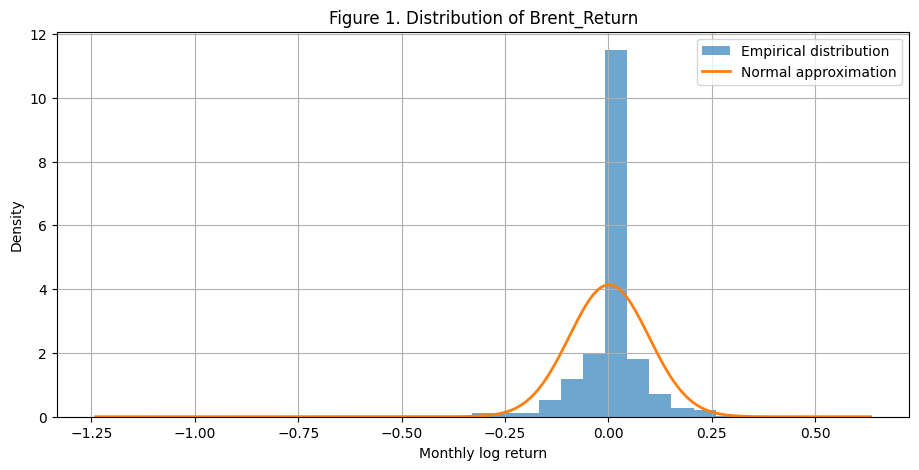

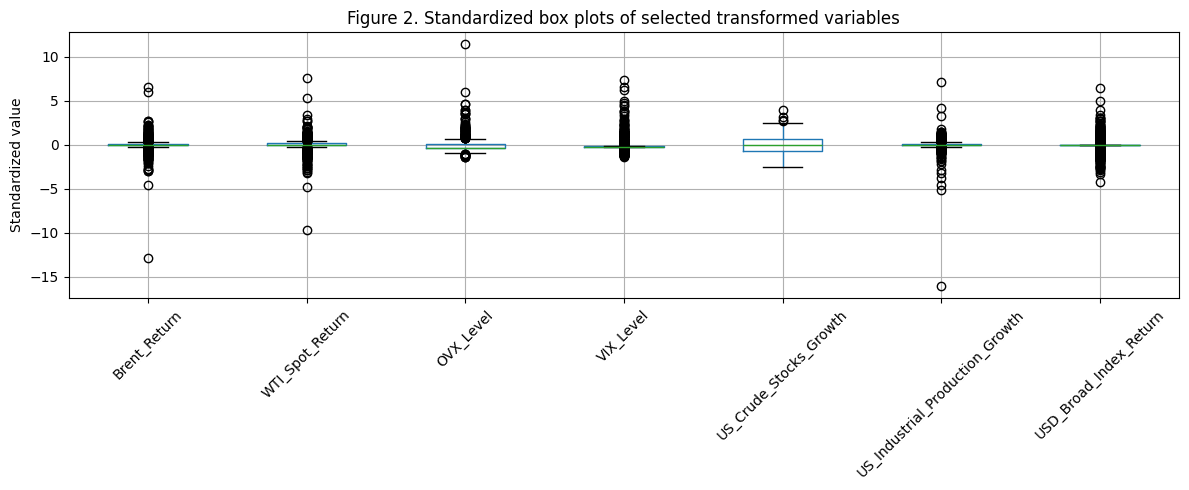

In [53]:
# ============================================================
# 5. Distributional analysis
# ============================================================
target = "Brent_Return" if "Brent_Return" in transformed.columns else transformed.columns[0]

summary_stats = transformed.describe().T
summary_stats["skewness"] = transformed.skew()
summary_stats["excess_kurtosis"] = transformed.kurtosis()
summary_stats = summary_stats[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skewness", "excess_kurtosis"]]
print("Summary statistics of transformed variables:")
display(summary_stats.round(4))

# Jarque-Bera test for oil returns.
jb_stat, jb_pvalue = stats.jarque_bera(transformed[target].dropna())
print(f"Jarque-Bera test for {target}: statistic={jb_stat:.3f}, p-value={jb_pvalue:.6f}")
print("Interpretation: low p-values indicate a rejection of normality, consistent with heavy tails and/or skewness.")

# Figure 1: histogram and normal overlay.
ret = transformed[target].dropna()
fig, ax = plt.subplots(figsize=(11,5))
ax.hist(ret, bins=35, density=True, alpha=0.65, label="Empirical distribution")
x = np.linspace(ret.min(), ret.max(), 300)
ax.plot(x, stats.norm.pdf(x, ret.mean(), ret.std(ddof=1)), linewidth=2, label="Normal approximation")
ax.set_title(f"Figure 1. Distribution of {target}")
ax.set_xlabel("Monthly log return")
ax.set_ylabel("Density")
ax.legend()
plt.show()

# Figure 2: box plots of selected variables.
selected_for_box = [target]
for candidate in ["WTI_Spot_Return", "OVX_Level", "VIX_Level", "US_Crude_Stocks_Growth", "US_Industrial_Production_Growth", "USD_Broad_Index_Return", "SP500_Return"]:
    if candidate in transformed.columns and candidate not in selected_for_box:
        selected_for_box.append(candidate)
selected_for_box = selected_for_box[:8]

scaled_for_box = pd.DataFrame(StandardScaler().fit_transform(transformed[selected_for_box]), index=transformed.index, columns=selected_for_box)
fig, ax = plt.subplots(figsize=(12,5))
scaled_for_box.boxplot(ax=ax, rot=45)
ax.set_title("Figure 2. Standardized box plots of selected transformed variables")
ax.set_ylabel("Standardized value")
plt.tight_layout()
plt.show()

## 6. Exploratory data analysis — time-series plots

This section supports Student B’s role. It visualizes oil prices, oil returns and volatility proxies to identify spikes, volatility clustering, structural breaks and abnormal periods.

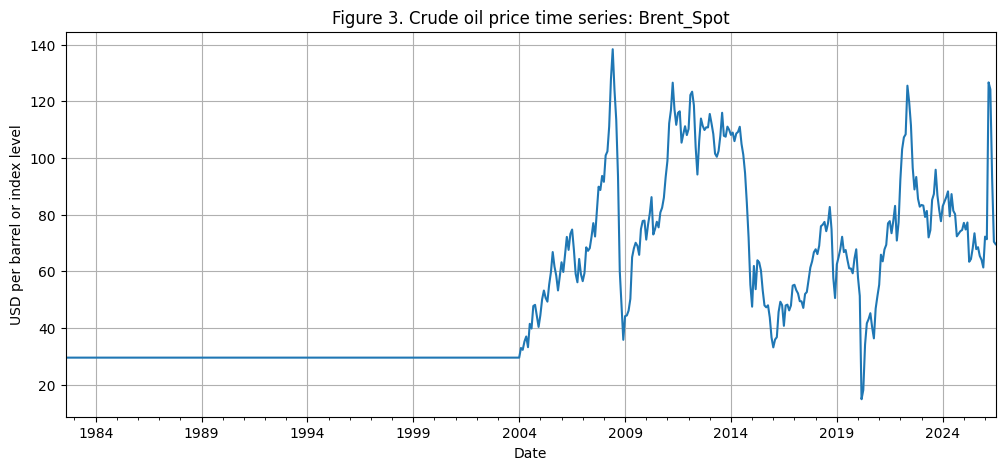

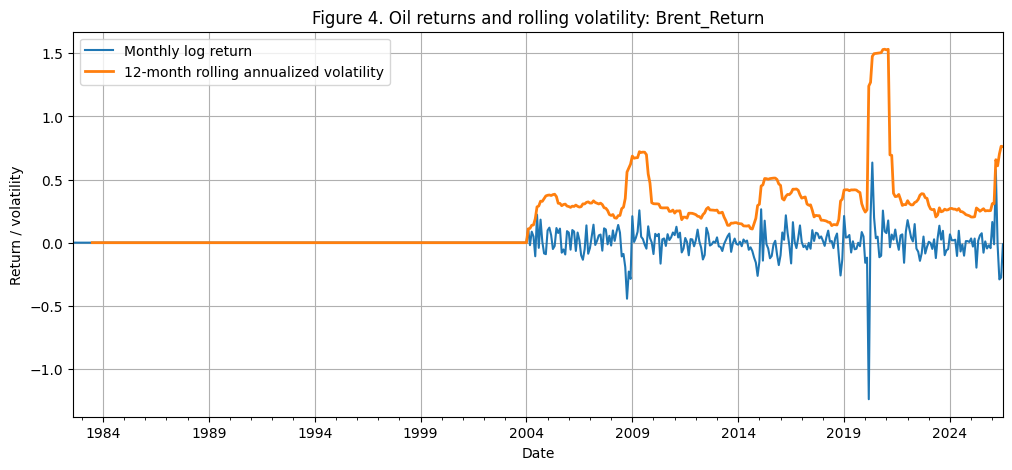

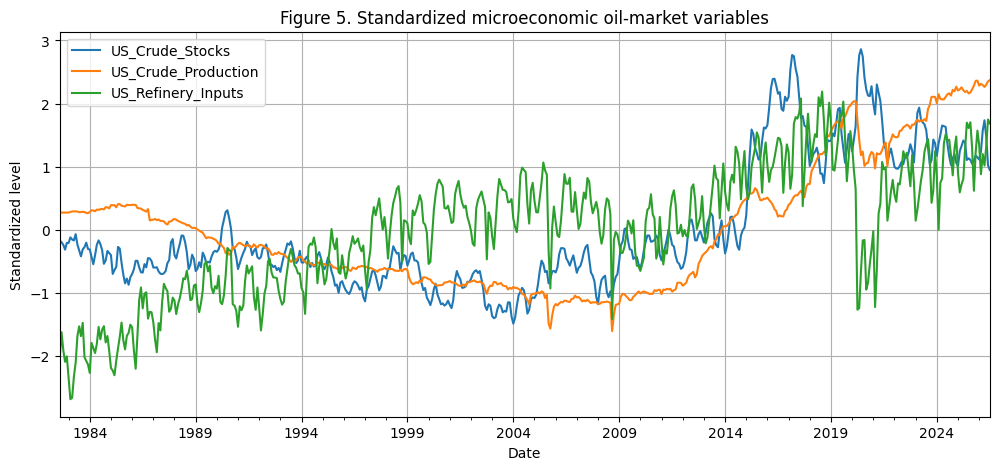

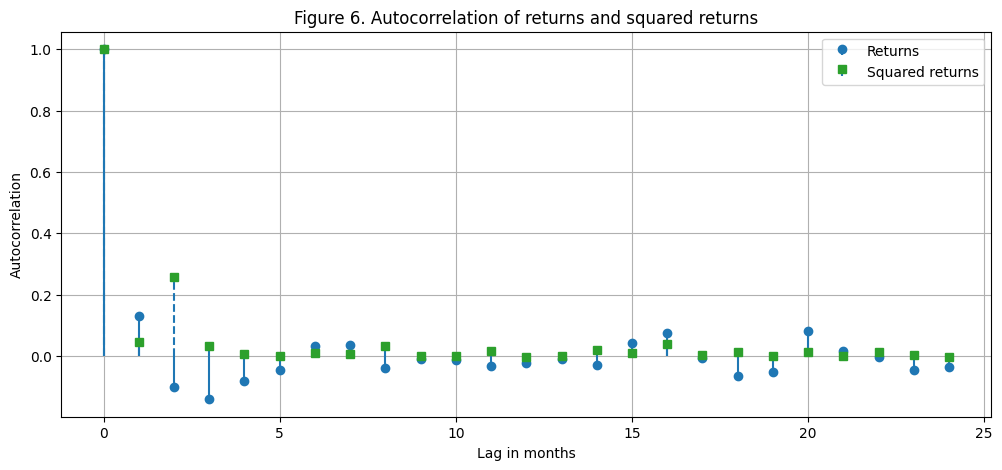

In [54]:
# ============================================================
# 6. Time-series analysis
# ============================================================
# Figure 3: crude oil price level.
price_col = "Brent_Spot" if "Brent_Spot" in cleaned.columns else ("Brent_Futures" if "Brent_Futures" in cleaned.columns else cleaned.columns[0])
fig, ax = plt.subplots(figsize=(12,5))
cleaned[price_col].plot(ax=ax)
ax.set_title(f"Figure 3. Crude oil price time series: {price_col}")
ax.set_xlabel("Date")
ax.set_ylabel("USD per barrel or index level")
plt.show()

# Figure 4: oil return time series and rolling volatility.
rolling_vol = transformed[target].rolling(12).std() * np.sqrt(12)
fig, ax = plt.subplots(figsize=(12,5))
transformed[target].plot(ax=ax, label="Monthly log return")
rolling_vol.plot(ax=ax, label="12-month rolling annualized volatility", linewidth=2)
ax.set_title(f"Figure 4. Oil returns and rolling volatility: {target}")
ax.set_xlabel("Date")
ax.set_ylabel("Return / volatility")
ax.legend()
plt.show()

# Figure 5: microeconomic variables if available.
micro_candidates = [c for c in ["US_Crude_Stocks", "US_Crude_Production", "US_Refinery_Inputs"] if c in cleaned.columns]
if micro_candidates:
    fig, ax = plt.subplots(figsize=(12,5))
    tmp = pd.DataFrame(StandardScaler().fit_transform(cleaned[micro_candidates]), index=cleaned.index, columns=micro_candidates)
    tmp.plot(ax=ax)
    ax.set_title("Figure 5. Standardized microeconomic oil-market variables")
    ax.set_xlabel("Date")
    ax.set_ylabel("Standardized level")
    ax.legend()
    plt.show()
else:
    print("No microeconomic variables available for Figure 5.")

# Figure 6: ACF of returns and squared returns.
if STATSMODELS_AVAILABLE:
    max_lag = 24
    acf_ret = acf(transformed[target].dropna(), nlags=max_lag, fft=False)
    acf_sq = acf((transformed[target].dropna()**2), nlags=max_lag, fft=False)
    fig, ax = plt.subplots(figsize=(12,5))
    ax.stem(range(max_lag+1), acf_ret, linefmt="-", markerfmt="o", basefmt=" ", label="Returns")
    ax.stem(range(max_lag+1), acf_sq, linefmt="--", markerfmt="s", basefmt=" ", label="Squared returns")
    ax.set_title("Figure 6. Autocorrelation of returns and squared returns")
    ax.set_xlabel("Lag in months")
    ax.set_ylabel("Autocorrelation")
    ax.legend()
    plt.show()
else:
    print("statsmodels unavailable; ACF plot skipped.")

## 7. Exploratory data analysis — multivariate plots

This section supports Student C’s role. It examines correlations and co-movements that can later guide the probabilistic graphical model.

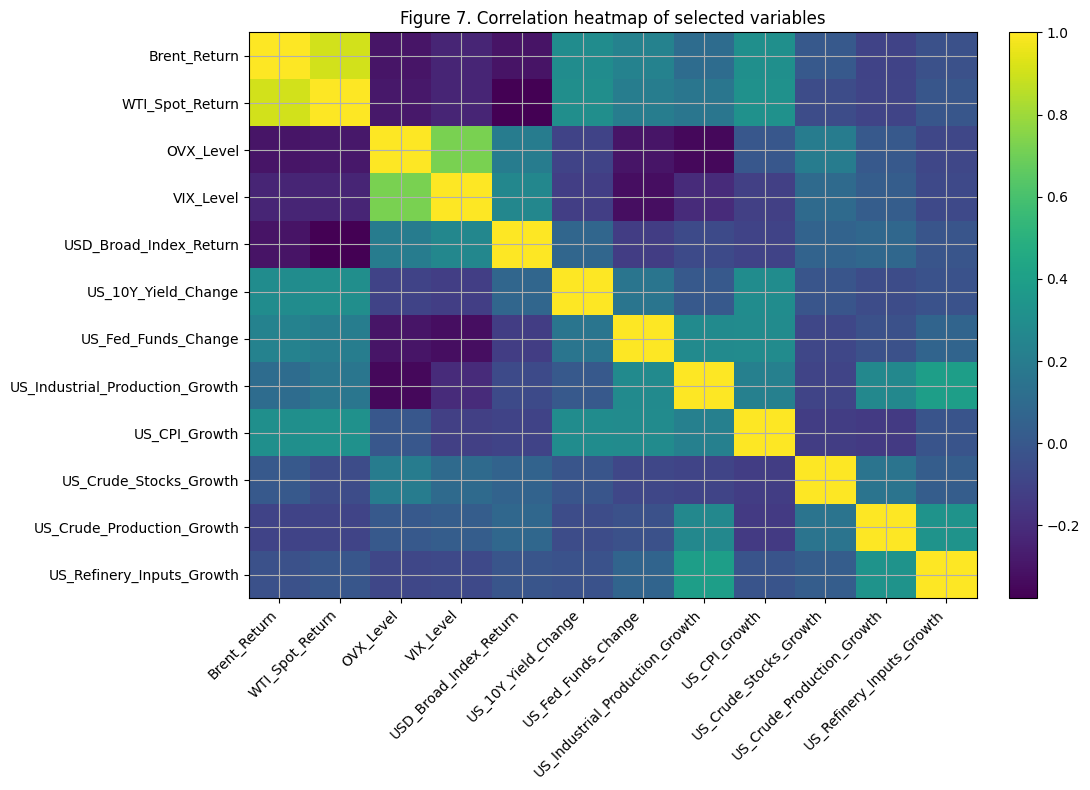

,Brent_Return,WTI_Spot_Return,OVX_Level,VIX_Level,USD_Broad_Index_Return,US_10Y_Yield_Change,US_Fed_Funds_Change,US_Industrial_Production_Growth,US_CPI_Growth,US_Crude_Stocks_Growth,US_Crude_Production_Growth,US_Refinery_Inputs_Growth
Brent_Return,1.000,0.908,-0.298,-0.235,-0.303,0.292,0.233,0.108,0.306,0.009,-0.102,-0.034
WTI_Spot_Return,0.908,1.000,-0.288,-0.237,-0.377,0.305,0.209,0.162,0.320,-0.057,-0.097,-0.010
OVX_Level,-0.298,-0.288,1.000,0.724,0.200,-0.101,-0.300,-0.345,-0.004,0.200,0.008,-0.084
VIX_Level,-0.235,-0.237,0.724,1.000,0.263,-0.122,-0.328,-0.206,-0.115,0.099,0.030,-0.072
USD_Broad_Index_Return,-0.303,-0.377,0.200,0.263,1.000,0.080,-0.124,-0.070,-0.098,0.061,0.081,-0.015
US_10Y_Yield_Change,0.292,0.305,-0.101,-0.122,0.080,1.000,0.156,0.007,0.295,-0.013,-0.056,-0.029
US_Fed_Funds_Change,0.233,0.209,-0.300,-0.328,-0.124,0.156,1.000,0.282,0.285,-0.086,-0.038,0.065
US_Industrial_Production_Growth,0.108,0.162,-0.345,-0.206,-0.070,0.007,0.282,1.000,0.225,-0.096,0.265,0.394
US_CPI_Growth,0.306,0.320,-0.004,-0.115,-0.098,0.295,0.285,0.225,1.000,-0.125,-0.145,-0.018
US_Crude_Stocks_Growth,0.009,-0.057,0.200,0.099,0.061,-0.013,-0.086,-0.096,-0.125,1.000,0.152,0.029


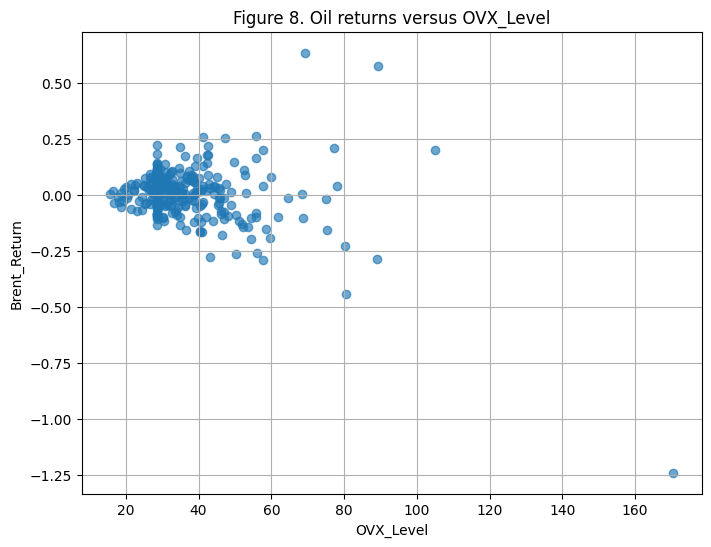

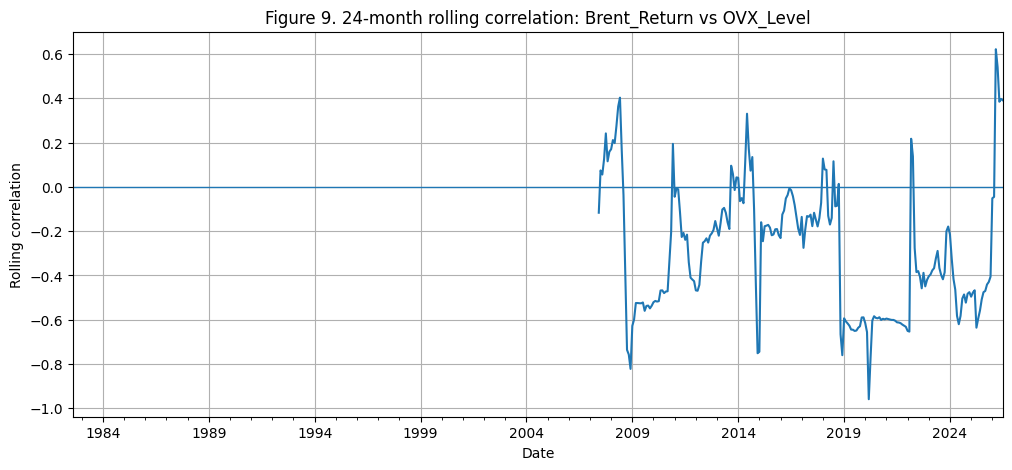

In [55]:
# ============================================================
# 7. Multivariate analysis
# ============================================================
# Select variables with sufficient variation.
analysis_cols = transformed.select_dtypes(include=[np.number]).columns.tolist()
# Keep a manageable number for the report figure.
priority = [
    "Brent_Return", "WTI_Spot_Return", "OVX_Level", "VIX_Level", "USD_Broad_Index_Return", "Dollar_Index_Return",
    "US_10Y_Yield_Change", "US_Fed_Funds_Change", "US_Industrial_Production_Growth", "US_CPI_Growth",
    "US_Crude_Stocks_Growth", "US_Crude_Production_Growth", "US_Refinery_Inputs_Growth", "SP500_Return", "Geopolitical_Risk_Level"
]
selected = [c for c in priority if c in analysis_cols]
if len(selected) < 4:
    selected = analysis_cols[:min(10, len(analysis_cols))]

corr = transformed[selected].corr(method="pearson")

# Figure 7: correlation heatmap.
fig, ax = plt.subplots(figsize=(11,8))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
ax.set_title("Figure 7. Correlation heatmap of selected variables")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

display(corr.round(3))

# Figure 8: scatter plot oil return vs a risk proxy.
risk_proxy = None
for c in ["OVX_Level", "VIX_Level", "Geopolitical_Risk_Level", "US_Crude_Stocks_Growth"]:
    if c in transformed.columns:
        risk_proxy = c
        break
if risk_proxy:
    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(transformed[risk_proxy], transformed[target], alpha=0.65)
    ax.set_title(f"Figure 8. Oil returns versus {risk_proxy}")
    ax.set_xlabel(risk_proxy)
    ax.set_ylabel(target)
    plt.show()

# Figure 9: rolling correlation with risk proxy.
if risk_proxy:
    roll_corr = transformed[target].rolling(24).corr(transformed[risk_proxy])
    fig, ax = plt.subplots(figsize=(12,5))
    roll_corr.plot(ax=ax)
    ax.axhline(0, linewidth=1)
    ax.set_title(f"Figure 9. 24-month rolling correlation: {target} vs {risk_proxy}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Rolling correlation")
    plt.show()

## 8. Stylized-facts diagnostics

This section converts the plots into diagnostics that support the discussion in the report template: heavy tails, volatility clustering, autocorrelation and abnormal oil-market episodes.

In [56]:
# ============================================================
# 8. Stylized facts: tests and technical interpretation
# ============================================================
ret = transformed[target].dropna()

diagnostics = {
    "target_variable": target,
    "observations": int(ret.shape[0]),
    "mean_monthly_return": float(ret.mean()),
    "monthly_volatility": float(ret.std(ddof=1)),
    "annualized_volatility": float(ret.std(ddof=1) * np.sqrt(12)),
    "skewness": float(stats.skew(ret)),
    "excess_kurtosis": float(stats.kurtosis(ret, fisher=True)),
    "jarque_bera_stat": float(jb_stat),
    "jarque_bera_pvalue": float(jb_pvalue),
}

if STATSMODELS_AVAILABLE:
    lb_ret = acorr_ljungbox(ret, lags=[6, 12], return_df=True)
    lb_sq = acorr_ljungbox(ret**2, lags=[6, 12], return_df=True)
    diagnostics["ljung_box_return_pvalue_lag12"] = float(lb_ret.loc[12, "lb_pvalue"])
    diagnostics["ljung_box_squared_return_pvalue_lag12"] = float(lb_sq.loc[12, "lb_pvalue"])

stylized_facts = pd.DataFrame.from_dict(diagnostics, orient="index", columns=["value"])
display(stylized_facts)

print("Technical interpretation:")
print("1. Excess kurtosis materially above zero supports the heavy-tail hypothesis.")
print("2. A low Jarque-Bera p-value rejects normality of oil returns.")
if STATSMODELS_AVAILABLE:
    print("3. If squared-return Ljung-Box p-values are low, volatility clustering is present even when raw return autocorrelation is weak.")
print("4. Rolling volatility and time-series plots identify stress periods and regime changes relevant for risk management.")

,value
target_variable,Brent_Return
observations,528
mean_monthly_return,0.001623
monthly_volatility,0.096434
annualized_volatility,0.334057
skewness,-3.360134
excess_kurtosis,57.778607
jarque_bera_stat,74437.647335
jarque_bera_pvalue,0.0
ljung_box_return_pvalue_lag12,0.000997


Technical interpretation:
1. Excess kurtosis materially above zero supports the heavy-tail hypothesis.
2. A low Jarque-Bera p-value rejects normality of oil returns.
3. If squared-return Ljung-Box p-values are low, volatility clustering is present even when raw return autocorrelation is weak.
4. Rolling volatility and time-series plots identify stress periods and regime changes relevant for risk management.


## 9. Probabilistic graphical model preparation

A full Bayesian network will be developed in later stages of the mini-capstone. For GWP1, this notebook produces a preliminary dependence network and identifies an empirical Markov blanket around the oil-return target. Continuous variables are discretized into Low/Medium/High states for Bayesian-network readiness.

Candidate variables ranked by mutual information with the target:


,variable,correlation_with_target,mutual_information
0,WTI_Spot_Return,0.9077,0.8853
4,US_10Y_Yield_Change,0.2924,0.4620
7,US_CPI_Growth,0.3061,0.4355
2,VIX_Level,-0.2346,0.4354
6,US_Industrial_Production_Growth,0.1081,0.4158
3,USD_Broad_Index_Return,-0.3029,0.3936
1,OVX_Level,-0.2975,0.3815
5,US_Fed_Funds_Change,0.2329,0.1859
10,US_Refinery_Inputs_Growth,-0.0340,0.0478
8,US_Crude_Stocks_Growth,0.0091,0.0382


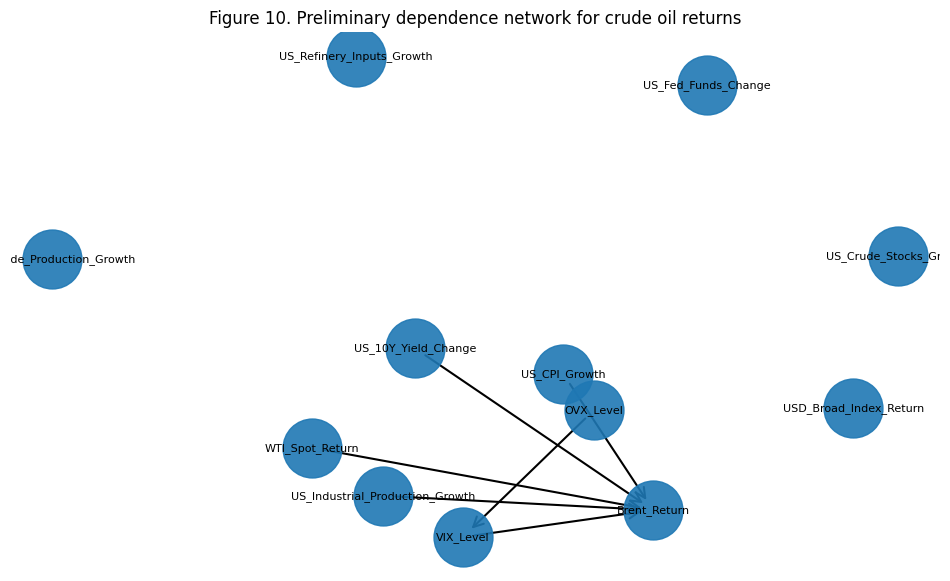

Empirical Markov blanket proxy for Brent_Return :
['US_10Y_Yield_Change', 'US_CPI_Growth', 'US_Industrial_Production_Growth', 'VIX_Level', 'WTI_Spot_Return']
Discretized states sample:


,Brent_Return_State,WTI_Spot_Return_State,VIX_Level_State,US_10Y_Yield_Change_State,US_Industrial_Production_Growth_State,US_CPI_Growth_State
2026-03-31,High,High,High,High,Low,High
2026-04-30,Low,High,High,High,High,High
2026-05-31,Low,Low,Low,High,High,High
2026-06-30,Low,Low,Low,Low,High,Medium
2026-07-31,Low,Low,Low,High,High,Medium


In [57]:
# ============================================================
# 9. Discretization and preliminary dependence network
# ============================================================

def discretize_series(s, labels=("Low", "Medium", "High")):
    """Quantile-based discretization with fallback for low-variation series."""
    try:
        return pd.qcut(s.rank(method="first"), q=len(labels), labels=labels)
    except Exception:
        return pd.cut(s, bins=len(labels), labels=labels)

# Use variables with enough observations and variation.
model_cols = selected.copy()
if target not in model_cols:
    model_cols = [target] + model_cols
model_cols = list(dict.fromkeys(model_cols))[:12]
model_data = transformed[model_cols].dropna().copy()

# Standardize for mutual information and correlation.
X_numeric = pd.DataFrame(StandardScaler().fit_transform(model_data), index=model_data.index, columns=model_data.columns)

discrete_data = pd.DataFrame(index=model_data.index)
for col in model_data.columns:
    discrete_data[col + "_State"] = discretize_series(model_data[col]).astype(str)

target_state = target + "_State"

# Mutual information with target.
mi_results = []
for col in model_data.columns:
    if col == target:
        continue
    try:
        mi = mutual_info_regression(X_numeric[[col]], X_numeric[target], random_state=CONFIG["random_seed"])[0]
    except Exception:
        mi = np.nan
    corr_val = model_data[col].corr(model_data[target])
    mi_results.append({"variable": col, "correlation_with_target": corr_val, "mutual_information": mi})
mi_table = pd.DataFrame(mi_results).sort_values("mutual_information", ascending=False)
print("Candidate variables ranked by mutual information with the target:")
display(mi_table.round(4))

# Preliminary dependence graph: target-connected Markov-blanket proxy + selected pairwise edges.
G = nx.DiGraph()
for col in model_cols:
    G.add_node(col)

# Add edges into target for top MI variables; use temporal/economic orientation proxy.
top_predictors = mi_table.head(min(5, len(mi_table)))["variable"].tolist()
for pred in top_predictors:
    G.add_edge(pred, target)

# Add additional dependence edges among non-target variables by absolute correlation.
corr_model = model_data.corr().abs()
for i, a in enumerate(model_cols):
    for b in model_cols[i+1:]:
        if a == target or b == target:
            continue
        if corr_model.loc[a, b] >= 0.45:
            # Orient edge by a simple ordering: macro/micro/financial listed earlier toward later variables.
            G.add_edge(a, b)

fig, ax = plt.subplots(figsize=(12,7))
pos = nx.spring_layout(G, seed=CONFIG["random_seed"], k=0.9)
nx.draw_networkx_nodes(G, pos, node_size=1800, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=18, width=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
ax.set_title("Figure 10. Preliminary dependence network for crude oil returns")
ax.axis("off")
plt.show()

# Empirical Markov blanket proxy: parents and children around target in the preliminary graph.
parents = list(G.predecessors(target))
children = list(G.successors(target))
co_parents = []
for child in children:
    co_parents.extend([p for p in G.predecessors(child) if p != target])
markov_blanket_proxy = sorted(set(parents + children + co_parents))
print("Empirical Markov blanket proxy for", target, ":")
print(markov_blanket_proxy)

print("Discretized states sample:")
display(discrete_data[[c for c in discrete_data.columns if c.replace('_State','') in [target] + markov_blanket_proxy]].tail())

## 10. Pseudocode for inferred causality

The following pseudocode is the group-level algorithm that links GWP1 data preparation with the Bayesian-network methodology expected in subsequent project stages.

In [58]:
# ============================================================
# 10. Pseudocode as a report-ready text block
# ============================================================
pseudocode = """
Algorithm: Inferred Causality for Crude Oil Price Forecasting

Input:
    - Target variable: crude oil price return.
    - Candidate predictors: macroeconomic, geopolitical, microeconomic and financial variables.
    - Cleaned and transformed monthly dataset.

Steps:
    1. Define the target variable as crude oil price return.
    2. Collect candidate predictors from macroeconomic/geopolitical, microeconomic and financial categories.
    3. Clean the data by detecting outliers, correcting bad data and imputing missing values.
    4. Align all variables to a common monthly frequency and transform them to comparable stationary forms.
    5. Estimate pairwise dependence using correlation and mutual information.
    6. Discretize continuous variables into Low, Medium and High states.
    7. Identify the empirical Markov blanket of the oil-return target.
    8. Retain variables that provide conditional information about the target.
    9. Orient edges using temporal ordering, economic reasoning and conditional-dependence evidence.
    10. Construct a preliminary directed acyclic graph.
    11. Validate the network structure using statistical diagnostics and economic interpretation.
    12. Use the validated structure for parameter learning and probabilistic inference in GWP2/GWP3.

Output:
    - Cleaned dataset.
    - Exploratory figures.
    - Stylized-facts diagnostics.
    - Preliminary network structure.
    - Markov-blanket variables for the crude-oil target.
"""
print(pseudocode)


Algorithm: Inferred Causality for Crude Oil Price Forecasting

Input:
    - Target variable: crude oil price return.
    - Candidate predictors: macroeconomic, geopolitical, microeconomic and financial variables.
    - Cleaned and transformed monthly dataset.

Steps:
    1. Define the target variable as crude oil price return.
    2. Collect candidate predictors from macroeconomic/geopolitical, microeconomic and financial categories.
    3. Clean the data by detecting outliers, correcting bad data and imputing missing values.
    4. Align all variables to a common monthly frequency and transform them to comparable stationary forms.
    5. Estimate pairwise dependence using correlation and mutual information.
    6. Discretize continuous variables into Low, Medium and High states.
    7. Identify the empirical Markov blanket of the oil-return target.
    8. Retain variables that provide conditional information about the target.
    9. Orient edges using temporal ordering, economic reas

## 11. Report-ready conclusions generated from the notebook

The next cell prints concise text that can be adapted directly into the report’s EDA and stylized-facts sections.

In [59]:
# ============================================================
# 11. Auto-generated technical conclusions
# ============================================================
ex_kurt = diagnostics["excess_kurtosis"]
skew = diagnostics["skewness"]
normality = "rejected" if diagnostics["jarque_bera_pvalue"] < 0.05 else "not rejected"
vol_cluster_sentence = ""
if STATSMODELS_AVAILABLE:
    if diagnostics.get("ljung_box_squared_return_pvalue_lag12", 1.0) < 0.05:
        vol_cluster_sentence = "Squared-return autocorrelation is statistically significant at the 12-month lag, supporting volatility clustering."
    else:
        vol_cluster_sentence = "Squared-return autocorrelation is not statistically significant at the 12-month lag in this sample."

print("Report-ready EDA conclusions:")
print(f"The target variable is {target}. The estimated annualized volatility is {diagnostics['annualized_volatility']:.2%}.")
print(f"The empirical distribution has skewness of {skew:.3f} and excess kurtosis of {ex_kurt:.3f}.")
print(f"The Jarque-Bera test {normality} normality at the 5% significance level.")
if vol_cluster_sentence:
    print(vol_cluster_sentence)
print(f"The preliminary Markov-blanket proxy includes: {', '.join(markov_blanket_proxy) if markov_blanket_proxy else 'no variables selected'}.")
print("These findings justify using a probabilistic graphical model because the target variable is affected by multiple interdependent risk factors and displays non-normal behavior.")

Report-ready EDA conclusions:
The target variable is Brent_Return. The estimated annualized volatility is 33.41%.
The empirical distribution has skewness of -3.360 and excess kurtosis of 57.779.
The Jarque-Bera test rejected normality at the 5% significance level.
Squared-return autocorrelation is statistically significant at the 12-month lag, supporting volatility clustering.
The preliminary Markov-blanket proxy includes: US_10Y_Yield_Change, US_CPI_Growth, US_Industrial_Production_Growth, VIX_Level, WTI_Spot_Return.
These findings justify using a probabilistic graphical model because the target variable is affected by multiple interdependent risk factors and displays non-normal behavior.
